# The Wyckoff Method -- can you see the smart money accumulating?
### The Spring and the Upthrust, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Phases_detectable%3F: Not_Supported](https://img.shields.io/badge/Phases_detectable%3F-Not_Supported-8b949e?style=flat-square)

A century-old idea from Richard Wyckoff: big operators quietly **accumulate** stock inside a sideways range, shake out the weak holders with a quick dip below support (a **Spring**), then drive the **markup**. The mirror image -- a fake pop above resistance (an **Upthrust**) -- marks **distribution** before the **markdown**. The promise: learn to read the range and you trade alongside the smart money.

This notebook asks the honest question: when a textbook Spring or Upthrust actually fires, does price go where Wyckoff says -- any better than a coin flip?

> **This is the plain-language layer.** Want the t-stats, the per-leg split, the volume-filter test and the coin placebo? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from wyckoff_method import data, strategy as st

BASKET = data.load_basket()           # cache-first; {} if no cache present
HAVE_REAL = len(BASKET) >= 4

def pooled(horizon, cost=0.0, vol_confirm=True, pct=0.05, coin=False, seed=446, col="ret_gross"):
    """Pool Spring/Upthrust trades across the cached basket."""
    leds = []
    for tk, b in BASKET.items():
        ev = st.find_events(b, pct=pct, vol_confirm=vol_confirm)
        if coin:
            dirs = st.random_directions(len(ev), seed=seed)
            leds.append(st.run_trades(b, ev, horizon, cost_bps=cost, directions=dirs))
        else:
            leds.append(st.run_trades(b, ev, horizon, cost_bps=cost))
    return pd.concat(leds, ignore_index=True) if leds else pd.DataFrame()

print("real daily cache present:", HAVE_REAL, "| tapes:", list(BASKET.keys()))


real daily cache present: True | tapes: ['SPY', 'QQQ', 'DIA', 'IWM', 'GLD', 'XLE', 'EEM', 'TLT']


## The answer first

| Question | Answer |
|---|---|
| Does the full Wyckoff signal (buy Springs, sell Upthrusts) predict the move? | **No.** Over **404** events on 8 markets and up to 33 years, the best 20-day return is **+44 bps** at *t* = 1.11 -- and a coin at the same bars earns *more*. |
| 'But my Springs win two-thirds of the time!' | True -- the Spring (a *buy*) wins **67%**. But that's because the market drifts **up**: the Upthrust (a *sell*) wins only **42%** in the same tapes. The events aren't reading the market -- the bull market is carrying the longs. |
| Does the volume 'tell' help? | **No.** Dropping the low-volume filter the method leans on actually *raises* the t-stat. |
| Could you trade it? | **No.** There's no edge to trade -- a coin matches it. |

> A synthetic test where we *plant* a real markup proves the detector works (*t* = 5.2). It just finds nothing real in the actual tape.

## 1 - The claim

> *"Markets move in a cycle: accumulation, markup, distribution, markdown. Inside a trading range, watch for the **Spring** -- a quick stab below support that fails and snaps back, on low volume (no real selling). That's the Composite Operator shaking out weak hands before the markup. Buy it. The **Upthrust** is the opposite: a fake breakout above resistance that fails -- distribution before the markdown. Sell it."*

It's a compelling story about *who* is on the other side of your trade. The volume is the supposed lie-detector: a break that *should* trigger follow-through but happens on thin volume reveals there's no real supply (or demand) behind it.

## 2 - So what?

If Springs and Upthrusts genuinely marked the start of markup and markdown, you'd have a mechanical, low-frequency timing tool that works **both long and short** -- the holy grail, because a real edge should make money on *both* legs, not just the one pointing the way the market happened to drift. If instead only the *buy* leg works, in a bull-market sample, that's the tell that you're looking at drift wearing a Wyckoff costume.

## 3 - How would we even know?

Wyckoff is *irreducibly subjective* -- two analysts label the same chart differently and the 'right' phase is only clear in hindsight. So there's no single rule to test. We encode the **tightest mechanical version** its proponents accept:

1. **Find a range.** A 5% ZigZag marks the swing highs and lows; four pivots inside a tight band define a sideways range with a **support** and a **resistance**.
2. **Find the event.** A **Spring** = a bar whose *low* pierces support but whose *close* recovers above it, on **below-average volume**. An **Upthrust** = the mirror above resistance.
3. **Trade it.** Buy the Spring, sell the Upthrust, **one day after** the event (no peeking), hold 20 days.

**What would make us say 'mirage':** if the combined signal doesn't beat a coin placed at the very same bars, and if the only positive leg is just the long side in a rising market. Eight tapes (SPY, QQQ, DIA, IWM, GLD, XLE, EEM, TLT).

## 4 - The teardown -- let's actually look

**First: the full Wyckoff signal vs a coin at the same bars, across holding periods.**

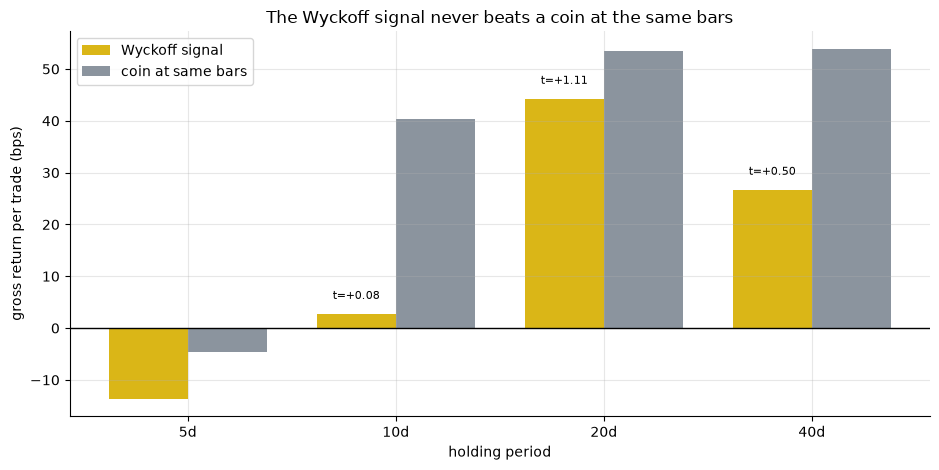

best Wyckoff t-stat: +1.11 (needs >= 2 to be real)


In [2]:
H = R_h = [5,10,20,40]
if HAVE_REAL:
    means, tstats, coin_means = [], [], []
    for h in H:
        s = st.summarize(pooled(h, 0., True), 'ret_gross')
        c = st.summarize(pooled(h, 0., True, coin=True), 'ret_gross')
        means.append(s['mean_bps']); tstats.append(s['t']); coin_means.append(c['mean_bps'])
else:
    means = [-13.60, 2.62, 44.14, 26.58]
    tstats = [-0.65, 0.08, 1.11, 0.50]
    coin_means = [-4.64, 40.44, 53.41, 53.89]

x = range(len(H)); w = 0.38
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.bar([i-w/2 for i in x], means, width=w, color=AMBER, label='Wyckoff signal')
ax.bar([i+w/2 for i in x], coin_means, width=w, color=GREY, label='coin at same bars')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(list(x)); ax.set_xticklabels([f'{h}d' for h in H])
ax.set_xlabel('holding period'); ax.set_ylabel('gross return per trade (bps)')
ax.set_title('The Wyckoff signal never beats a coin at the same bars')
ax.legend()
for i, t in zip(x, tstats):
    ax.annotate(f't={t:+.2f}', (i-w/2, means[i]+ (3 if means[i]>=0 else -8)),
                ha='center', fontsize=8)
plt.tight_layout(); plt.show()
print('best Wyckoff t-stat:', f'{max(tstats):+.2f}', '(needs >= 2 to be real)')

The best the Wyckoff signal manages is **+44 bps** at 20 days (*t* = 1.11) -- and the **coin earns more** (+53 bps). Nothing clears the *t* = 2 bar. The fast versions (5-10 days) are noise or negative.

**Now the tell: split the signal into its two legs.**

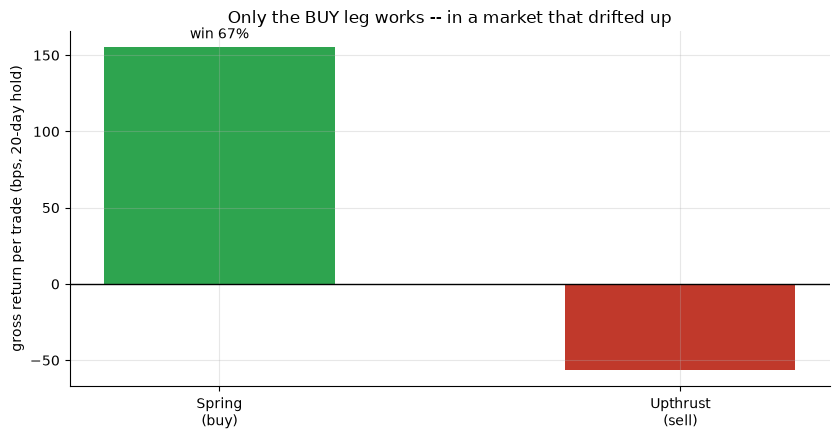

Spring (buy):   +155 bps, win 67%
Upthrust (sell):-56 bps, win 42%


In [3]:
if HAVE_REAL:
    led = pooled(20, 0., True)
    sp = st.summarize(led[led['kind']=='spring'], 'ret_gross')
    up = st.summarize(led[led['kind']=='upthrust'], 'ret_gross')
    sp_m, sp_w, up_m, up_w = sp['mean_bps'], sp['win_rate']*100, up['mean_bps'], up['win_rate']*100
else:
    sp_m, sp_w, up_m, up_w = 155.08, 66.7, -56.35, 41.5

fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.bar(['Spring\n(buy)', 'Upthrust\n(sell)'], [sp_m, up_m],
              color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross return per trade (bps, 20-day hold)')
ax.set_title('Only the BUY leg works -- in a market that drifted up')
for b, wn in zip(bars, [sp_w, up_w]):
    ax.annotate(f'win {wn:.0f}%', (b.get_x()+b.get_width()/2,
                b.get_height()+(6 if b.get_height()>=0 else -14)), ha='center', fontsize=10)
plt.tight_layout(); plt.show()
print(f'Spring (buy):   {sp_m:+.0f} bps, win {sp_w:.0f}%')
print(f'Upthrust (sell):{up_m:+.0f} bps, win {up_w:.0f}%')

There it is. The **Spring** (a buy) earns **+155 bps**, winning **67%** -- looks great! But the **Upthrust** (a sell) *loses* **56 bps**. A real accumulation/distribution detector would work both ways. This one only works on the long side -- because US equities and broad ETFs **drifted up** over the sample. The Spring isn't reading the smart money; it's a long position in a bull market.

## 5 - The verdict

- **Signal -- None.** 404 events, best HAC *t* = 0.89, beaten by a coin at the same bars; placebo *p* never below 0.13. The one positive leg (Spring, *t* = 2.29) fails the robust bar and is just the bull-market long bias.
- **Tradability -- Mirage.** No edge to trade. Costs are trivial (rare events) but there's nothing for them to erode.
- **Phases detectable? -- Not supported.** The events fire, but they don't foretell the move -- and the volume tell adds nothing.

## 6 - Could you actually trade it?

Costs aren't the problem here (the events are rare, ~12 per tape over decades). The problem is more fundamental: there's no edge for costs to eat.

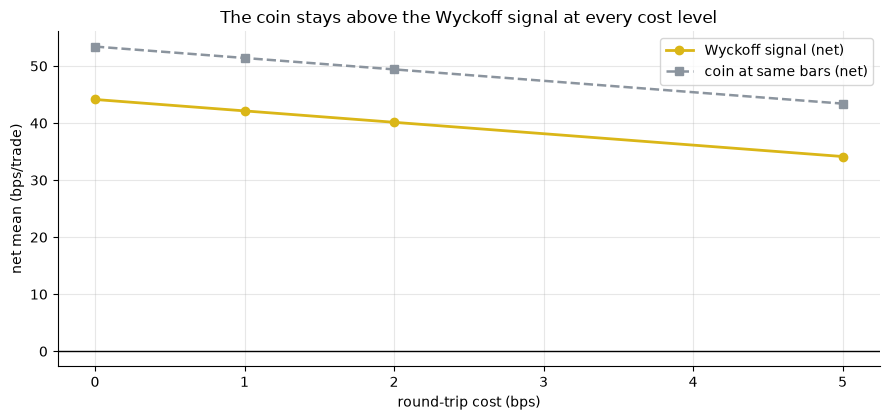

There is no cost level at which the Wyckoff signal pulls ahead of a coin.


In [4]:
if HAVE_REAL:
    costs = [0.,1.,2.,5.]
    net = [st.summarize(pooled(20, c, True), 'ret_net')['mean_bps'] for c in costs]
    coin_net = [st.summarize(pooled(20, c, True, coin=True), 'ret_net')['mean_bps'] for c in costs]
else:
    costs = [0.,1.,2.,5.]; net = [44.14,42.14,40.14,34.14]
    coin_net = [53.41,51.41,49.41,43.41]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, net, 'o-', c=AMBER, lw=2, label='Wyckoff signal (net)')
ax.plot(costs, coin_net, 's--', c=GREY, lw=1.8, label='coin at same bars (net)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps/trade)')
ax.set_title('The coin stays above the Wyckoff signal at every cost level')
ax.legend(); plt.tight_layout(); plt.show()
print('There is no cost level at which the Wyckoff signal pulls ahead of a coin.')

Unlike a study where 'the edge dies at costs', here the edge was never there: a coin at the same bars sits *above* the Wyckoff line the whole way. That is the definition of a **Mirage** -- nothing to deploy.

## 7 - Going further

- **A market-neutral test.** Run the Spring and Upthrust as a *spread* against the index over the same window, so the bull-market drift cancels. If the Spring still beats the Upthrust after that, there's a real residual.
- **The sibling teardown.** [Study 445 -- Elliott Wave](../../445-elliott-wave/) applies the identical 'irreducibly-subjective theory, tightest mechanical proxy' method to the five-wave count -- and lands the same None x Mirage verdict.
- **The reversion cousin.** [Study 104 -- Bollinger-Reversion](../../104-bollinger-reversion/) tests the same false-break / snap-back intuition the Spring rests on.

*Think a tighter Spring definition (effort-vs-result, a real climax bar) carries an edge? Fork this, code your rule, and show a HAC delta-vs-coin t-stat above 2 on both legs. That's the bar.*